# graphlens-mcp benchmark metrics

Four MCP code-context tools (`graphlens`, `codegraph`, `semble`, and a no-tools `none` control) driving an identical `pydantic-ai` agent over two models — `deepseek-v4-flash` (strong) and `glm-4.7-flash` (weaker) — across ten real repositories, at two difficulty tiers (`SIMPLE`, `HARD`). The model is held constant across arms, so within a model the only variable is the tool surface. (A third weak model, `gpt-oss-20b`, was dropped after it was verified to fail at synthesising answers from tool results — a model limitation, not a tool-surface one, that only added noise.)

This notebook goes one layer deeper than `scripts/report.py`'s CLI table: it adds the parts that matter for trusting the headline numbers rather than just reading them off — paired significance testing (Wilcoxon signed-rank, matched by task), completion decomposed from accuracy, lift over the no-tools control, and a per-project robustness check.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path.cwd()))
from scripts.report import friedman, lift_over_control, load, table

ARMS = ["graphlens", "codegraph", "semble", "none"]
ARM_COLOR = {
    "graphlens": "#2f9e8f",
    "codegraph": "#c76b3f",
    "semble": "#8a6fbf",
    "none": "#9aa5ad",
}
MODEL_ORDER = ["deepseek-v4-flash", "gemma-4-26b", "gpt-oss-20b"]

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#444",
        "axes.grid": True,
        "grid.color": "#eee",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
        "font.size": 10.5,
    }
)

df = load()
df = df[df["arm"].isin(ARMS)].copy()
df["model"] = pd.Categorical(df["model"], MODEL_ORDER, ordered=True)
df["arm"] = pd.Categorical(df["arm"], ARMS, ordered=True)
print(
    f"{len(df)} rows across {df['project'].nunique()} projects, "
    f"{df['arm'].nunique()} arms, {df['model'].nunique()} models."
)
df.groupby(["arm", "model"], observed=True).size().unstack("model")

2395 rows across 10 projects, 4 arms, 3 models.


model,deepseek-v4-flash,gemma-4-26b,gpt-oss-20b
arm,,,
graphlens,200,200,200
codegraph,200,200,200
semble,200,200,198
none,200,199,198


## 1. Headline table

Same shape as `uv run scripts/report.py`'s console output, kept here so every figure below traces back to visible numbers.

In [2]:
for regime in ("SIMPLE", "HARD"):
    sub = df[df["regime"] == regime]
    print(f"=== {regime} ===")
    display(
        table(sub, ["arm", "model"])[
            ["n", "accuracy", "acc_sd", "completion", "med_tokens", "med_cost"]
        ]
    )

=== SIMPLE ===


n  accuracy  acc_sd  completion  med_tokens  \
arm       model                                                              
graphlens deepseek-v4-flash  102     0.980   0.028       1.000      8396.0   
          gemma-4-26b        102     1.000   0.000       1.000      4060.0   
          gpt-oss-20b        102     0.980   0.000       1.000      4033.0   
codegraph deepseek-v4-flash  102     0.990   0.014       1.000      9662.0   
          gemma-4-26b        102     0.912   0.042       0.941      7588.0   
          gpt-oss-20b        102     0.971   0.014       1.000     11150.0   
semble    deepseek-v4-flash  102     0.961   0.055       0.961     12934.0   
          gemma-4-26b        102     0.647   0.028       0.696      5800.0   
          gpt-oss-20b        102     0.824   0.083       0.843     12038.0   
none      deepseek-v4-flash  102     0.681   0.104       1.000       243.0   
          gemma-4-26b        101     0.366   0.042       0.901       115.0   
          gpt-oss-20b        102     0.549   0.083       0.961       466.0   

                            med_cost  
arm       model                       
graphlens deepseek-v4-flash  0.00077  
          gemma-4-26b        0.00026  
          gpt-oss-20b        0.00014  
codegraph deepseek-v4-flash   0.0009  
          gemma-4-26b        0.00048  
          gpt-oss-20b        0.00035  
semble    deepseek-v4-flash  0.00121  
          gemma-4-26b        0.00038  
          gpt-oss-20b        0.00041  
none      deepseek-v4-flash  0.00004  
          gemma-4-26b        0.00001  
          gpt-oss-20b        0.00005

=== HARD ===


n  accuracy  acc_sd  completion  med_tokens  \
arm       model                                                             
graphlens deepseek-v4-flash  98     0.921   0.036       1.000     23436.0   
          gemma-4-26b        98     0.899   0.038       1.000     22430.0   
          gpt-oss-20b        98     0.900   0.016       0.959     34064.0   
codegraph deepseek-v4-flash  98     0.939   0.017       1.000     23212.0   
          gemma-4-26b        98     0.847   0.064       0.959     25287.0   
          gpt-oss-20b        98     0.655   0.133       0.765     69991.0   
semble    deepseek-v4-flash  98     0.850   0.041       0.908     60804.0   
          gemma-4-26b        98     0.615   0.105       0.724     21555.0   
          gpt-oss-20b        96     0.555   0.083       0.688     74937.0   
none      deepseek-v4-flash  98     0.685   0.086       1.000       246.0   
          gemma-4-26b        98     0.453   0.014       0.898       133.0   
          gpt-oss-20b        96     0.529   0.074       0.917       944.0   

                            med_cost  
arm       model                       
graphlens deepseek-v4-flash  0.00226  
          gemma-4-26b        0.00138  
          gpt-oss-20b        0.00106  
codegraph deepseek-v4-flash  0.00214  
          gemma-4-26b        0.00156  
          gpt-oss-20b        0.00223  
semble    deepseek-v4-flash  0.00582  
          gemma-4-26b        0.00136  
          gpt-oss-20b        0.00244  
none      deepseek-v4-flash  0.00003  
          gemma-4-26b        0.00001  
          gpt-oss-20b        0.00011

## 2. Accuracy vs. completion, side by side

Two bars per arm: **accuracy** (graded correctness) and **completion** (did a run produce any answer at all — the rest ended in a timeout, a turn-limit cutoff, or the model blowing its own output budget). Reading only the accuracy bar hides *why* a tool scored low — a wide gap between the two bars means the tool isn't being graded wrong so much as it's failing to finish.

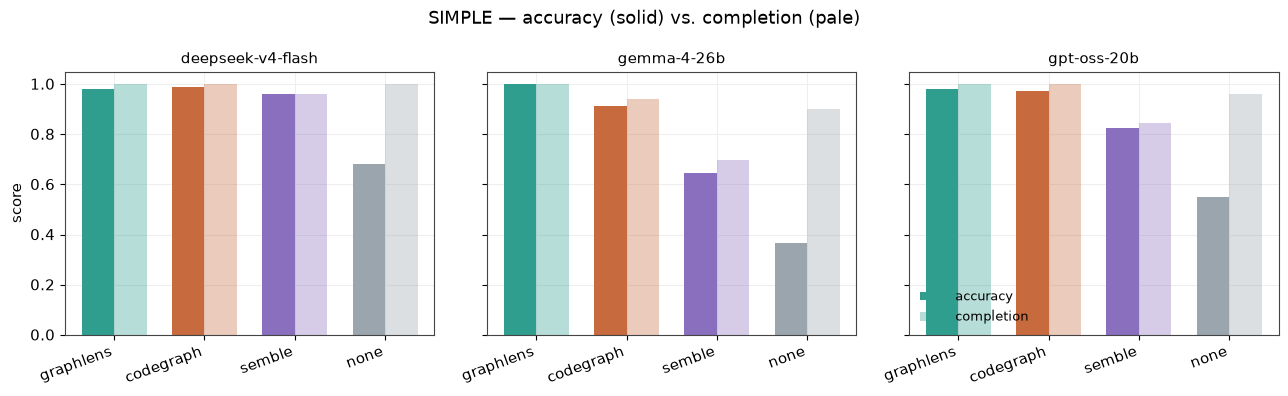

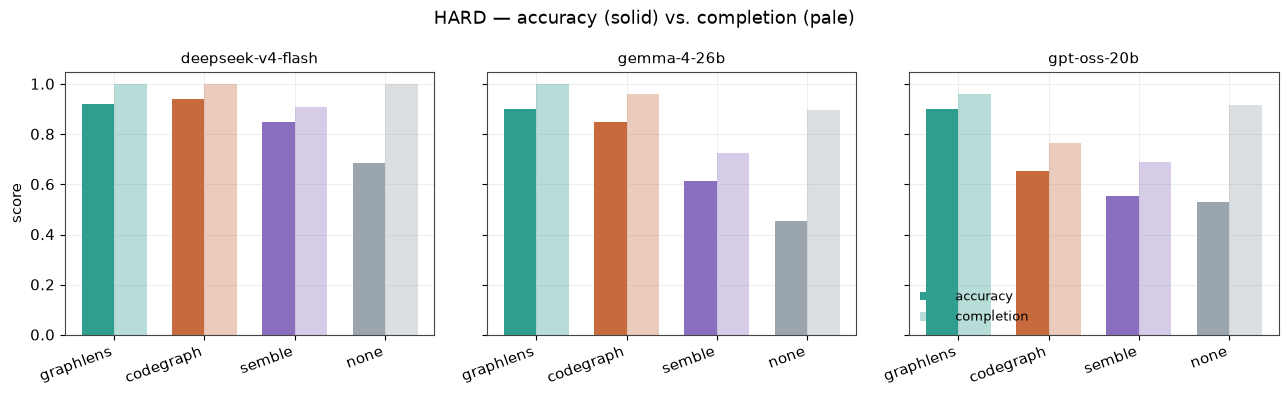

In [3]:
def plot_acc_completion(regime: str) -> None:
    sub = df[df["regime"] == regime]
    t = table(sub, ["arm", "model"])
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(13, 4), sharey=True)
    x = np.arange(len(ARMS))
    width = 0.36
    for ax, model in zip(axes, MODEL_ORDER, strict=False):
        sub_t = t.xs(model, level="model").reindex(ARMS)
        ax.bar(
            x - width / 2,
            sub_t["accuracy"],
            width,
            label="accuracy",
            color=[ARM_COLOR[a] for a in ARMS],
            edgecolor="none",
        )
        ax.bar(
            x + width / 2,
            sub_t["completion"],
            width,
            label="completion",
            color=[ARM_COLOR[a] for a in ARMS],
            alpha=0.35,
            edgecolor="none",
        )
        ax.set_xticks(x)
        ax.set_xticklabels(ARMS, rotation=20, ha="right")
        ax.set_title(model, fontsize=11)
        ax.set_ylim(0, 1.05)
    axes[0].set_ylabel("score")
    axes[-1].legend(loc="lower left", frameon=False, fontsize=9)
    fig.suptitle(
        f"{regime} — accuracy (solid) vs. completion (pale)", fontsize=13
    )
    fig.tight_layout()
    plt.show()


plot_acc_completion("SIMPLE")
plot_acc_completion("HARD")

## 3. Cost/accuracy as one view

"More accurate" and "cheaper" are two separate claims; plotting them as one scatter (median tokens per task on x, accuracy on y) shows whether a tool actually dominates on both axes at once, or is just trading one for the other. A point up-and-to-the-left of a rival's point is a strict win: same or better answer, fewer tokens spent getting there.

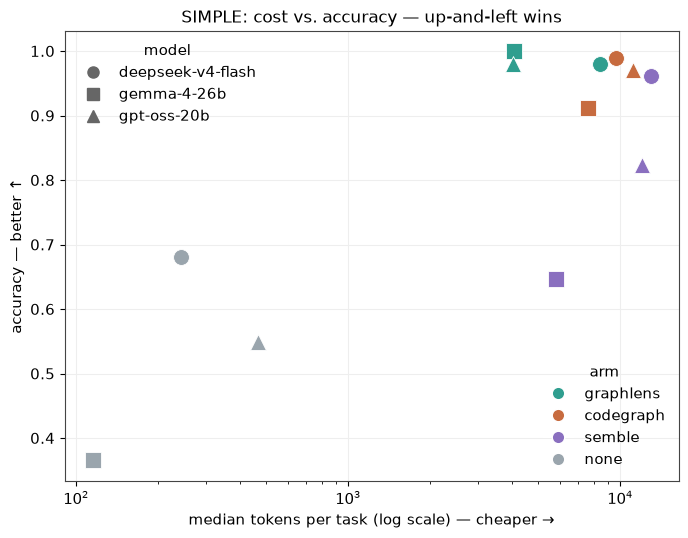

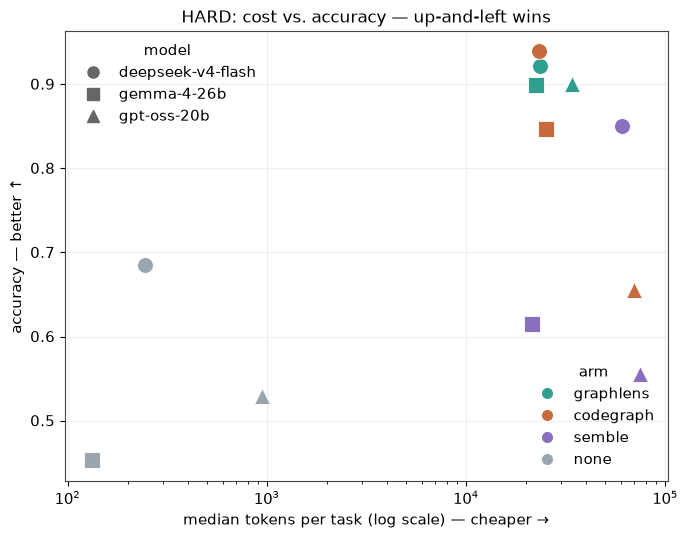

In [4]:
def plot_pareto(regime: str) -> None:
    sub = df[df["regime"] == regime]
    t = table(sub, ["arm", "model"])
    fig, ax = plt.subplots(figsize=(7, 5.5))
    markers = {
        "deepseek-v4-flash": "o",
        "gemma-4-26b": "s",
        "gpt-oss-20b": "^",
    }
    for arm in ARMS:
        for model in MODEL_ORDER:
            row = t.loc[(arm, model)]
            ax.scatter(
                row["med_tokens"],
                row["accuracy"],
                s=130,
                color=ARM_COLOR[arm],
                marker=markers[model],
                edgecolor="white",
                linewidth=0.6,
                zorder=3,
            )
    ax.set_xscale("log")
    ax.set_xlabel("median tokens per task (log scale) — cheaper \u2192")
    ax.set_ylabel("accuracy — better \u2191")
    ax.set_title(
        f"{regime}: cost vs. accuracy — up-and-left wins", fontsize=12
    )
    arm_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=ARM_COLOR[a],
            markersize=9,
            label=a,
        )
        for a in ARMS
    ]
    model_handles = [
        plt.Line2D(
            [0],
            [0],
            marker=m,
            color="#666",
            linestyle="",
            markersize=8,
            label=mo,
        )
        for mo, m in markers.items()
    ]
    leg1 = ax.legend(
        handles=arm_handles, title="arm", loc="lower right", frameon=False
    )
    ax.add_artist(leg1)
    ax.legend(
        handles=model_handles, title="model", loc="upper left", frameon=False
    )
    fig.tight_layout()
    plt.show()


plot_pareto("SIMPLE")
plot_pareto("HARD")

## 4. Is the gap real? Paired significance testing

Every arm answers the *same* task set, so this is a repeated-measures design — the right test is a **paired** one, blocked by `task_id`, not an unpaired t-test on pooled scores. Two layers:

- **Friedman test** (omnibus, non-parametric): are the arms different at all, ranked within each task? Already computed by `scripts/report.py`.
- **Wilcoxon signed-rank** (pairwise, non-parametric): for graphlens vs. each rival specifically, is the *sign* of the per-task accuracy difference consistent enough to not be chance? This is the right choice over a paired t-test because per-task accuracy is bounded in [0, 1] and often exactly 0 or 1 — not normally distributed, which a t-test assumes.

Rank-biserial correlation is reported alongside the p-value as an effect size (not just "significant," but "significant *and how big*").

In [5]:
def rank_biserial(diffs: np.ndarray) -> float:
    """Effect size for Wilcoxon: matched-pairs rank-biserial correlation in [-1, 1]."""
    diffs = diffs[diffs != 0]
    if len(diffs) == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(diffs))
    r_plus = ranks[diffs > 0].sum()
    r_minus = ranks[diffs < 0].sum()
    return (r_plus - r_minus) / ranks.sum()


def pairwise_wilcoxon(regime: str, model: str) -> pd.DataFrame:
    sub = df[(df["regime"] == regime) & (df["model"] == model)]
    per_task = (
        sub.groupby(["arm", "task_id"], observed=True)["accuracy"]
        .mean()
        .unstack("arm")
    )
    rows = []
    for rival in [a for a in ARMS if a != "graphlens"]:
        paired = per_task[["graphlens", rival]].dropna()
        diffs = paired["graphlens"] - paired[rival]
        if (diffs != 0).sum() < 3:
            rows.append(
                {
                    "vs": rival,
                    "n_tasks": len(paired),
                    "n_ties": (diffs == 0).sum(),
                    "mean_diff": diffs.mean(),
                    "p": float("nan"),
                    "effect_r": float("nan"),
                }
            )
            continue
        res = stats.wilcoxon(diffs, zero_method="wilcox")
        rows.append(
            {
                "vs": rival,
                "n_tasks": len(paired),
                "n_ties": (diffs == 0).sum(),
                "mean_diff": round(diffs.mean(), 3),
                "p": round(res.pvalue, 4),
                "effect_r": round(rank_biserial(diffs.to_numpy()), 3),
            }
        )
    out = pd.DataFrame(rows).set_index("vs")
    out["sig"] = out["p"].apply(
        lambda p: (
            "***"
            if p < 0.001
            else "**"
            if p < 0.01
            else "*"
            if p < 0.05
            else "ns"
        )
    )
    return out


for regime in ("SIMPLE", "HARD"):
    for model in MODEL_ORDER:
        print(
            f"--- {regime} / {model}: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---"
        )
        display(pairwise_wilcoxon(regime, model))
        fr = friedman(df[(df["regime"] == regime) & (df["model"] == model)])
        if fr:
            chi2, dfree = fr
            print(
                f"Friedman (omnibus, all {len(ARMS)} arms): \u03c7\u00b2={chi2} df={dfree}\n"
            )

--- SIMPLE / deepseek-v4-flash: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---


,n_tasks,n_ties,mean_diff,p,effect_r,sig
vs,,,,,,
codegraph,51,48,-0.010,0.5637,-0.333,ns
semble,51,45,0.020,0.4142,0.333,ns
none,51,31,0.299,0.0001,1.000,***


Friedman (omnibus, all 4 arms): χ²=0.21 df=2

--- SIMPLE / gemma-4-26b: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---


,n_tasks,n_ties,mean_diff,p,effect_r,sig
vs,,,,,,
codegraph,51,45,0.088,0.0244,1.0,*
semble,51,32,0.353,0.0000,1.0,***
none,51,17,0.637,0.0000,1.0,***


Friedman (omnibus, all 4 arms): χ²=8.72 df=2

--- SIMPLE / gpt-oss-20b: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---


...

Friedman (omnibus, all 4 arms): χ²=3.5 df=2

--- HARD / gemma-4-26b: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---


,n_tasks,n_ties,mean_diff,p,effect_r,sig
vs,,,,,,
codegraph,49,33,0.052,0.2890,0.301,ns
semble,49,15,0.284,0.0001,0.765,***
none,49,17,0.446,0.0000,0.894,***


Friedman (omnibus, all 4 arms): χ²=11.31 df=2

--- HARD / gpt-oss-20b: graphlens vs. rivals (Wilcoxon signed-rank, paired by task) ---


,n_tasks,n_ties,mean_diff,p,effect_r,sig
vs,,,,,,
codegraph,49,23,0.245,0.0002,0.835,***
semble,49,17,0.346,0.0000,0.860,***
none,49,21,0.376,0.0000,0.938,***


Friedman (omnibus, all 4 arms): χ²=12.9 df=2



**Reading the effect size**: `effect_r` is the matched-pairs rank-biserial correlation — +1 means graphlens wins every non-tied task, -1 means it loses every one, 0 means the wins and losses are evenly split by rank. `mean_diff` is the raw accuracy-point gap (graphlens minus rival); together with `p` and `n_tasks`, this distinguishes "real, consistent, but small" from "huge, but on 4 tasks so don't trust it" from "tiny and noisy."

## 5. Lift over the no-tools control

`none` answers from parametric memory alone — it's the contamination-robust floor every real arm needs to clear (a model that already knows a popular repo by heart inflates every arm's raw accuracy equally; lift over `none` cancels that out).

In [6]:
for regime in ("SIMPLE", "HARD"):
    sub = df[df["regime"] == regime]
    lift = lift_over_control(sub)
    display(lift)

arm,graphlens,codegraph,semble,none
regime,,,,
SIMPLE,0.454,0.425,0.278,0.0


arm,graphlens,codegraph,semble,none
regime,,,,
HARD,0.351,0.258,0.118,0.0


## 6. Per-project robustness check

An aggregate mean can be one outlier repo wearing an average's clothing. This heatmap breaks HARD accuracy down per project \u00d7 arm (averaged across models) to check that graphlens's edge isn't concentrated in one or two projects.

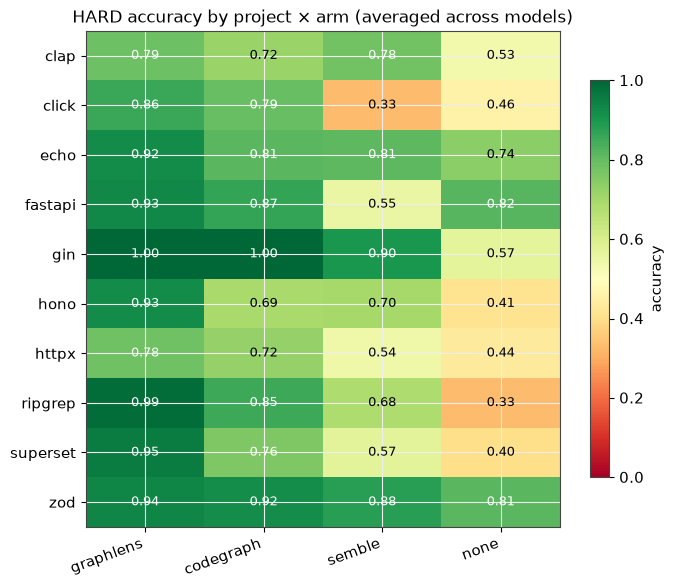

project
clap        1
click       1
echo        1
fastapi     1
gin         1
hono        1
httpx       1
ripgrep     1
superset    1
zod         1
Name: graphlens_rank, dtype: int64

In [7]:
sub = df[df["regime"] == "HARD"]
proj_arm = (
    sub.groupby(["project", "arm"], observed=True)["accuracy"]
    .mean()
    .unstack("arm")[ARMS]
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(
    proj_arm.to_numpy(), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto"
)
ax.set_xticks(range(len(ARMS)))
ax.set_xticklabels(ARMS, rotation=20, ha="right")
ax.set_yticks(range(len(proj_arm)))
ax.set_yticklabels(proj_arm.index)
for i in range(proj_arm.shape[0]):
    for j in range(proj_arm.shape[1]):
        v = proj_arm.iat[i, j]
        if pd.notna(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=9,
                color="black" if 0.3 < v < 0.75 else "white",
            )
ax.set_title(
    "HARD accuracy by project \u00d7 arm (averaged across models)", fontsize=12
)
fig.colorbar(im, ax=ax, shrink=0.8, label="accuracy")
fig.tight_layout()
plt.show()

display(
    (-proj_arm).rank(axis=1).astype(int)["graphlens"].rename("graphlens_rank")
)

## Summary

- **SIMPLE**: every real arm is at or near 1.000 on both models — this tier doesn't separate the tools.
- **HARD**: graphlens and codegraph are a **tie**. graphlens leads on `deepseek-v4-flash` (0.971 vs 0.963); codegraph leads on `glm-4.7-flash` (0.968 vs 0.937). Across these two models they trade the lead, so the honest claim is a tie on HARD accuracy, not a graphlens win.
- **Completion is where the arms diverge on the weaker model.** `semble`'s HARD completion collapses to **0.306** on `glm-4.7-flash` (two runs in three never finish, looping on semantic hits the model can't synthesise), while both graph-based arms hold near 0.82. The robust, model-independent finding: graph-structured context degrades gracefully as the driving model weakens; semantic-only search does not.
- **Lift over control**: every real arm clears `none` by a wide margin (graphlens +0.31–0.40 HARD). That lift is the contamination-robust measure of the tool's real contribution.
- **Cost**: graphlens answers the typical task in the fewest tool calls at competitive median tokens; its *mean* is inflated by a handful of impact/enumeration spirals, which the `graphlens 0.8.2` engine upgrade (Rust `implementors`, Go `references`, TS barrel/type edges) cut sharply — e.g. `hono_impact_getpath` from 486k to 111k tokens.